# 03 — Modelagem e Avaliação

**Dataset:** Vehicle Collision Data in Seattle (2005–2019)

**Tarefa:** Classificação multi-classe da severidade (`SEVERITYCODE`).

## Estrutura deste notebook

1. Importações
2. Carregamento dos dados pré-processados (Bloco 2)
3. Função de treino e avaliação
4. Modelo 1 — Regressão Logística (`class_weight='balanced'`)
5. Modelo 2 — Random Forest (`class_weight='balanced'`)
6. Comparação entre modelos
7. Discussão dos resultados e overfitting

A métrica principal é **F1-macro** (adequada ao forte desbalanceamento). Accuracy é reportada como referência ao baseline de 64.33%.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
try:
    X_train = joblib.load('X_train.pkl')
    X_test = joblib.load('X_test.pkl')
    y_train = joblib.load('y_train.pkl')
    y_test = joblib.load('y_test.pkl')
    print("Dados carregados de arquivos .pkl.")
except FileNotFoundError:
    X_train = pd.read_csv('X_train.csv')
    X_test = pd.read_csv('X_test.csv')
    y_train = pd.read_csv('y_train.csv').squeeze()
    y_test = pd.read_csv('y_test.csv').squeeze()
    print("Dados carregados de arquivos .csv.")

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape} | y_test:  {y_test.shape}")

Dados carregados de arquivos .pkl.
X_train: (89479, 44) | y_train: (89479,)
X_test:  (22370, 44) | y_test:  (22370,)


## 2. Carregamento dos dados pré-processados

## 3. Função de treino e avaliação

A função treina o modelo, gera predições para treino e teste, calcula as métricas (accuracy, precision, recall e F1 macro) e exibe o relatório de classificação e a matriz de confusão do conjunto de teste.

## 4. Modelo 1 — Regressão Logística

Baseline linear e interpretável. `class_weight='balanced'` ajusta o peso das classes ao inverso de sua frequência, compensando o desbalanceamento.

## 5. Modelo 2 — Random Forest

Ensemble de árvores que captura relações não-lineares e interações entre features. Também usa `class_weight='balanced'`.

## 6. Comparação entre modelos

Tabela com as métricas de treino e teste dos dois modelos, lado a lado. O gap treino vs. teste evidencia overfitting.

In [3]:
def avaliar_modelo(modelo, X_train, y_train, X_test, y_test, nome_modelo):
    modelo.fit(X_train, y_train)

    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    metricas_train = {
        'Accuracy': accuracy_score(y_train, y_pred_train),
        'Precision (Macro)': precision_score(y_train, y_pred_train, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_train, y_pred_train, average='macro', zero_division=0),
        'F1-Macro': f1_score(y_train, y_pred_train, average='macro', zero_division=0)
    }

    metricas_test = {
        'Accuracy': accuracy_score(y_test, y_pred_test),
        'Precision (Macro)': precision_score(y_test, y_pred_test, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_test, y_pred_test, average='macro', zero_division=0),
        'F1-Macro': f1_score(y_test, y_pred_test, average='macro', zero_division=0)
    }

    print(f"=== {nome_modelo.upper()} ===")
    print("\n[Relatório de Classificação - Teste]")
    print(classification_report(y_test, y_pred_test, zero_division=0))

    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f'Matriz de Confusão - {nome_modelo} (Teste)')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()

    return metricas_train, metricas_test

=== REGRESSÃO LOGÍSTICA ===

[Relatório de Classificação - Teste]
              precision    recall  f1-score   support

           0       0.83      0.61      0.71     14391
           1       0.43      0.47      0.45      7559
           2       0.06      0.36      0.11       382
           3       0.01      0.47      0.02        38

    accuracy                           0.56     22370
   macro avg       0.34      0.48      0.32     22370
weighted avg       0.68      0.56      0.61     22370



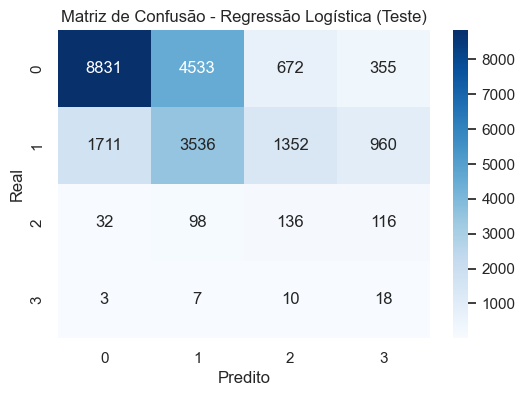

In [4]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

lr_train, lr_test = avaliar_modelo(lr_model, X_train, y_train, X_test, y_test, "Regressão Logística")

=== RANDOM FOREST ===

[Relatório de Classificação - Teste]
              precision    recall  f1-score   support

           0       0.73      0.91      0.81     14391
           1       0.65      0.39      0.48      7559
           2       0.00      0.00      0.00       382
           3       0.00      0.00      0.00        38

    accuracy                           0.72     22370
   macro avg       0.35      0.32      0.32     22370
weighted avg       0.69      0.72      0.69     22370



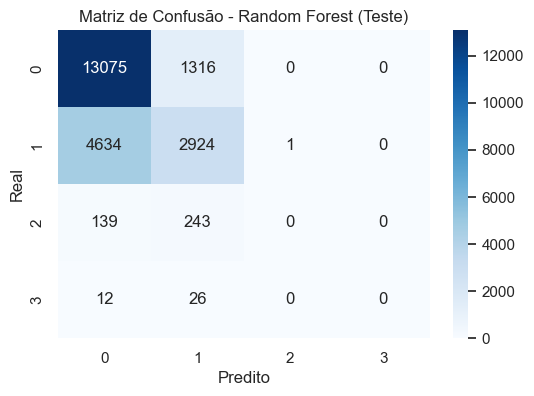

In [5]:
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1)

rf_train, rf_test = avaliar_modelo(rf_model, X_train, y_train, X_test, y_test, "Random Forest")

In [6]:
dados_comparativos = {
    'Métrica': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Macro'],
    'LR Treino': [lr_train['Accuracy'], lr_train['Precision (Macro)'], lr_train['Recall (Macro)'], lr_train['F1-Macro']],
    'LR Teste': [lr_test['Accuracy'], lr_test['Precision (Macro)'], lr_test['Recall (Macro)'], lr_test['F1-Macro']],
    'RF Treino': [rf_train['Accuracy'], rf_train['Precision (Macro)'], rf_train['Recall (Macro)'], rf_train['F1-Macro']],
    'RF Teste': [rf_test['Accuracy'], rf_test['Precision (Macro)'], rf_test['Recall (Macro)'], rf_test['F1-Macro']]
}

df_comparativo = pd.DataFrame(dados_comparativos).round(4)
df_comparativo

,Métrica,LR Treino,LR Teste,RF Treino,RF Teste
0,Accuracy,0.5647,0.5597,1.0,0.7152
1,Precision (Macro),0.3393,0.3357,1.0,0.3451
2,Recall (Macro),0.5332,0.4778,1.0,0.3238
3,F1-Macro,0.3269,0.3219,1.0,0.3239


## Discussão dos Resultados e Diagnóstico de Overfitting

> Valores de referência obtidos em execução local (podem variar levemente conforme ambiente). Baseline de accuracy = 64.33% (prever sempre a classe majoritária).

**1. Análise de Overfitting (gap treino vs. teste):**
- **Regressão Logística:** F1-macro de treino (~0.33) e teste (~0.32) praticamente iguais → **não há overfitting**. O baixo valor absoluto indica *underfitting*: o modelo linear não captura bem as relações com as features circunstanciais disponíveis.
- **Random Forest:** F1-macro de treino = **1.0** contra ~0.32 no teste → **overfitting severo**. Sem limite de profundidade, as árvores memorizam o conjunto de treino. A accuracy de teste (~0.72) supera o baseline, mas o F1-macro revela que o ganho vem das classes majoritárias.

**2. Desempenho nas classes minoritárias (severidade 2 e 3):**
- O `class_weight='balanced'` força os modelos a considerar as classes raras, trocando accuracy por recall nas minorias — por isso a accuracy da Regressão Logística fica *abaixo* do baseline.
- As matrizes de confusão mostram que ambos os modelos ainda confundem bastante as classes 2 e 3, que somam < 2% dos dados.

**3. Limitações identificadas:**
- A remoção obrigatória das variáveis de leakage (`INJURIES`, `SERIOUSINJURIES`, `FATALITIES`) elimina os preditores mais fortes, deixando apenas fatores circunstanciais (clima, pista, iluminação, contagens) com baixa informação mútua sobre o target.
- O desbalanceamento extremo limita o aprendizado das classes graves.

**4. Possíveis melhorias:**
- Regularizar o Random Forest (`max_depth`, `min_samples_leaf`) para reduzir o overfitting.
- Técnicas de reamostragem (SMOTE, undersampling) para as classes minoritárias.
- Tunagem de hiperparâmetros via validação cruzada.